# HEAPO Fault Detection — Validation Analysis (Tasks 4–13)

*Group 2 · Abdul — peer-comparison & fault-flagging workstream*

Every real-data test behind the numbers in `fault_detection.py`'s docstrings and in
`Four_Heat_Pump_Faults.pptx`'s appendix slides (5, 8, 10, 11, 13) -- now including Tasks
12-13, which close the two peer-matching gaps that were previously only asserted in
`fault_detection.py`'s docstrings (DHW-production-method match, EV-owner exclusion),
not yet run and validated live. This is the messy, exploratory analysis code —
`fault_detection.py` is the clean reference implementation that resulted from it.

Each task below is ONE cell: compute the real-data test, chart it, then validate it
against the exact numbers already reported this session (PASS/FAIL, not just a printout
to eyeball). Everything a task needs is computed inside that same cell, so **running
task cells out of order, or skipping one, cannot break another task cell.**

**The one real requirement: run the Setup cell once, first.** If you run a task cell
without having run Setup yet in this kernel (e.g. after Restart Kernel, clicking
straight into Task 5 instead of starting from the top), that cell now stops with one
clear message telling you to go run Setup — instead of a confusing NameError. Easiest
way to avoid this entirely: **Run > Run All Cells** (or *Restart Kernel and Run All* if
you've already run it once) rather than clicking into cells individually.

**How to run this:** the Setup cell below tries to auto-detect the folder holding your
local copies of the real HEAPO files (`meta_data.csv`, `protocols.csv`, `households.csv`,
the weather station files 8jB/Hg/z6I, and the per-household smart-meter CSVs — named with
the household ID anywhere in the filename, e.g. `858577.csv`, `hourly-858577.csv`,
`2024_858577_15min.csv` all match; daily or 15-min resolution both work). If it guesses
wrong you'll get a `FileNotFoundError` naming exactly what it searched — when that
happens, find that folder on your machine and either set it as the `HEAPO_DATA_DIR`
environment variable before launching Jupyter/VS Code, or edit the `DATA_DIR = ...` line
near the top of the Setup cell directly, then **Restart Kernel and Run All Cells**.

Easiest way to run this: **Run > Run All Cells** (or *Restart Kernel and Run All* if
you've already run it once) rather than clicking cells one at a time.

## 0. Setup — file finder, weather/household loaders, validation helper

Run this cell once, first. Everything below depends only on this, not on each other.

In [1]:
import glob
import os
import sys

try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
except ImportError as e:
    raise ImportError(
        f"Missing package: {e.name if hasattr(e, 'name') else e}.\n"
        f"This notebook needs numpy, pandas, and matplotlib in whichever Python "
        f"environment/kernel is selected for it (top-right of this window in VS Code, "
        f"or Kernel menu in Jupyter). Install them in that environment with:\n"
        f"    {sys.executable} -m pip install numpy pandas matplotlib\n"
        f"then Restart Kernel and Run All Cells."
    ) from e

plt.rcParams["figure.dpi"] = 110
FAULT_COLOR = "#C97A00"
CLEAN_COLOR = "#1E7A46"
NAVY = "#1E2761"

def _find_marker_dir(root, marker="meta_data.csv", max_depth=3, max_dirs_visited=5000):
    """
    Bounded search for `marker` under `root`, at most `max_depth` levels
    down. Deliberately NOT glob(..., recursive=True) with no depth limit --
    on a real machine `root` can be a home directory or similar, and an
    unbounded recursive scan there can hang for minutes crawling unrelated
    folders (site-packages, node_modules, cloud-sync caches, etc.). Skips
    common huge/irrelevant directories and gives up after visiting
    `max_dirs_visited` directories, so a bad guess fails fast instead of
    hanging. Returns the directory containing the marker file, or None.
    """
    skip = {".git", "node_modules", "__pycache__", ".venv", "venv", "site-packages",
            ".ipynb_checkpoints", "Library", "AppData", "$Recycle.Bin"}
    root_depth = root.rstrip(os.sep).count(os.sep)
    visited = 0
    for dirpath, dirnames, filenames in os.walk(root, followlinks=True):
        visited += 1
        if visited > max_dirs_visited:
            return None
        depth = dirpath.rstrip(os.sep).count(os.sep) - root_depth
        if depth >= max_depth:
            dirnames[:] = []
        dirnames[:] = [d for d in dirnames if d not in skip and not d.startswith(".")]
        if any(f.endswith(marker) for f in filenames):
            return dirpath
    return None


def _autodetect_data_dir():
    """
    Finds the folder holding the real HEAPO CSVs without requiring a manual
    edit. Tries, in order: the HEAPO_DATA_DIR environment variable, './data',
    the current directory, and the current directory's parent and
    grandparent -- each checked with a depth- and size-bounded search (see
    _find_marker_dir) so a wrong guess fails in under a second rather than
    hanging on an unrelated, huge folder. Returns the directory that actually
    contains meta_data.csv, or './data' as a last resort (which then raises a
    clear, actionable error the first time a file is looked up -- see _find).
    """
    candidates = []
    env_dir = os.environ.get("HEAPO_DATA_DIR")
    if env_dir:
        candidates.append(env_dir)
    cwd = os.getcwd()
    candidates += [
        os.path.join(cwd, "data"),
        cwd,
        os.path.dirname(cwd),
        os.path.dirname(os.path.dirname(cwd)),
    ]
    seen = set()
    for c in candidates:
        c = os.path.abspath(c)
        if c in seen or not os.path.isdir(c):
            continue
        seen.add(c)
        found = _find_marker_dir(c)
        if found:
            return found
    return "./data"


DATA_DIR = _autodetect_data_dir()  # auto-detected; override manually below if this guessed wrong
# DATA_DIR = "/path/to/your/HEAPO/folder"  # <-- uncomment and edit if auto-detection picked the wrong folder


def _find(pattern):
    matches = glob.glob(os.path.join(DATA_DIR, "**", pattern), recursive=True)
    if not matches:
        raise FileNotFoundError(
            f"No file matching {pattern!r} under DATA_DIR={DATA_DIR!r}.\n"
            f"This means the notebook could not auto-locate your HEAPO data folder.\n"
            f"Fix: find the folder on your machine containing meta_data.csv, protocols.csv, "
            f"households.csv, the weather station files, and the per-household CSVs, then "
            f"either (a) set it as the HEAPO_DATA_DIR environment variable before launching "
            f"Jupyter/VS Code, or (b) edit the DATA_DIR = ... line in this Setup cell to that "
            f"folder's path directly, then Restart Kernel and Run All Cells."
        )
    return matches


def find_reference_file(name):
    """meta_data.csv / protocols.csv / households.csv — exact-ish filename match."""
    matches = _find(f"*{name}")
    return matches[0]


def find_weather_file(station_id):
    """
    Finds the DAILY weather file for a station code (e.g. '8jB', 'Hg', 'z6I').
    Picks whichever match actually has daily columns, in case both an hourly
    and a daily file for the same station are present locally.
    """
    for path in _find(f"*{station_id}*.csv"):
        cols = pd.read_csv(path, sep=";", nrows=1).columns
        if "HeatingDegree_SIA_daily" in cols:
            return path
    raise FileNotFoundError(f"No DAILY weather file found for station {station_id}")


def load_weather_daily(station_id):
    w = pd.read_csv(find_weather_file(station_id), sep=";")
    w["Timestamp"] = pd.to_datetime(w["Timestamp"])
    w["d"] = w["Timestamp"].dt.date
    return w


def find_household_file(hh_id):
    """Returns every smart-meter file found for this household ID (there is
    often more than one local copy at different resolutions -- daily,
    15-min, monthly -- a recurring point of confusion earlier in this
    project). Use load_household_daily() rather than picking one yourself;
    it resolves this by actually loading each and keeping the one with the
    most daily coverage, not by guessing from file size or name."""
    candidates = [p for p in _find(f"*{hh_id}*.csv")
                  if "meta_data" not in p and "protocols" not in p and "households" not in p]
    if not candidates:
        raise FileNotFoundError(f"No smart-meter file found for household {hh_id}")
    return candidates


def _classify_interval(ts):
    """
    Classifies a sorted timestamp series as 'sub-daily', 'daily', or
    'monthly', from the MEDIAN gap between consecutive readings (median,
    not the first gap, so one irregular row can't fool it). This project's
    local files include, per household, several formats mixed together
    under near-identical filenames -- including monthly summaries stamped
    with a single end-of-month timestamp that looks like an ordinary row
    unless you check the gap to its neighbours.
    """
    if len(ts) < 2:
        return "daily"
    median_gap = ts.diff().dropna().median()
    if median_gap >= pd.Timedelta(days=20):
        return "monthly"
    elif median_gap >= pd.Timedelta(hours=6):
        return "daily"
    else:
        return "sub-daily"


def _is_cumulative(series):
    """
    Detects a running-total column mislabeled as a period reading: real
    consumption readings still tick down sometimes (meter noise, exports,
    corrections), while a cumulative counter is non-decreasing almost
    everywhere and its final value is many times a single period's typical
    size. Requires both, so a genuinely large-but-flat consumption series
    isn't misflagged.
    """
    s = series.dropna()
    if len(s) < 10:
        return False
    diffs = s.diff().dropna()
    if len(diffs) == 0:
        return False
    frac_nondecreasing = (diffs >= -1e-6).mean()
    typical_period_value = diffs.abs().median()
    total_span = s.iloc[-1] - s.iloc[0]
    return (frac_nondecreasing >= 0.98 and typical_period_value > 0
            and total_span > 20 * typical_period_value)


def _screen_outliers(daily_df, value_cols):
    """
    Drops individual days with a physically-implausible spike in any value
    column -- e.g. a meter re-sync or export glitch, such as one local
    household file that had a single 45,885 kWh day against a normal range
    of roughly 25-70 kWh/day for that household. Uses Tukey's rule (above
    Q3 + 5x the interquartile range), deliberately loose so real cold-snap
    peak days are kept; it's aimed at order-of-magnitude spikes, not
    ordinary variance.
    """
    if len(daily_df) < 10:
        return daily_df
    keep = pd.Series(True, index=daily_df.index)
    for c in value_cols:
        col = daily_df[c].dropna()
        if len(col) < 10:
            continue
        q1, q3 = col.quantile([0.25, 0.75])
        iqr = q3 - q1
        if iqr <= 0:
            continue
        upper = q3 + 5 * iqr
        keep &= daily_df[c].isna() | (daily_df[c] <= upper)
    return daily_df[keep].copy()


def _resample_to_daily(path, affects_filter=None):
    """
    Loads one candidate smart-meter file and returns (daily_df, interval,
    note). Returns (None, None, note) if the file isn't usable at daily
    resolution at all (monthly aggregates -- a single per-month total can't
    be mapped to a specific day's weather, which every regression in this
    analysis needs).

    Before resampling, each kWh column is checked for the cumulative
    running-total format (see _is_cumulative) and diffed back into period
    deltas if so, and after resampling, implausible single-day spikes are
    dropped (see _screen_outliers). Both problems were found in this
    project's real local files under filenames otherwise indistinguishable
    from the genuine daily/sub-daily ones.
    """
    df = pd.read_csv(path, sep=";")
    if affects_filter and "AffectsTimePoint" in df.columns:
        df = df[df["AffectsTimePoint"] == affects_filter]
    if len(df) == 0:
        return None, None, "empty after affects_filter"
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    df = df.sort_values("Timestamp")
    interval_class = _classify_interval(df["Timestamp"])
    interval = df["Timestamp"].diff().median() if len(df) > 1 else pd.Timedelta(days=1)

    if interval_class == "monthly":
        return None, None, "monthly aggregate (rejected -- not usable at daily resolution)"

    value_cols = [c for c in df.columns if c.startswith("kWh_received")]

    for c in value_cols:
        if _is_cumulative(df[c]):
            df[c] = df[c].diff()

    df["d"] = df["Timestamp"].dt.date
    if interval_class == "sub-daily":
        daily = df.groupby("d", as_index=False)[value_cols].sum(min_count=1)
    else:
        daily = df[["d"] + value_cols].copy()

    daily = _screen_outliers(daily, value_cols)
    return daily, interval, interval_class


def load_household_daily(hh_id, affects_filter=None):
    """
    Loads a household's smart-meter data and returns a DAILY dataframe with
    a 'd' (date) column and whichever kWh columns were present, resampled
    (summed) to daily if the source was sub-daily resolution.

    When multiple local files exist for the same household (common in this
    project -- daily/15-min/monthly variants, plus at least one cumulative
    running-total variant and one outlier-corrupted variant found among the
    real local files), each candidate is first classified and cleaned (see
    _resample_to_daily: monthly aggregates rejected, cumulative totals
    diffed back to deltas, implausible single-day spikes dropped), and
    ONLY THEN is the one giving the most daily rows after any
    affects_filter kept -- more real, clean data is better for the
    regressions used throughout this analysis. Rejected/cleaned candidates
    are recorded in `_rejected` for visibility.

    affects_filter: e.g. "before visit" -- applied to the raw AffectsTimePoint
    column BEFORE resampling, so it works correctly regardless of source
    resolution. Needed for any household whose file mixes multiple
    AffectsTimePoint periods (e.g. 112120 mixes before/after in one file).
    """
    paths = find_household_file(hh_id)
    best = None
    rejected = []
    for path in paths:
        daily, interval, note = _resample_to_daily(path, affects_filter)
        if daily is None:
            rejected.append((os.path.basename(path), note))
            continue
        if best is None or len(daily) > len(best[0]):
            best = (daily, path, interval)

    if best is None:
        raise FileNotFoundError(f"No usable data for household {hh_id} "
                                 f"(affects_filter={affects_filter!r}) among: {paths}\n"
                                 f"Rejected: {rejected}")

    daily, path, interval = best
    daily["_source_file"] = os.path.basename(path)
    daily["_source_interval"] = str(interval)
    daily.attrs["_rejected"] = rejected
    return daily


def hourly_load_profile(hh_id, kwh_col="kWh_received_Total", affects_filter=None):
    """
    For night-setback testing: returns average kW by hour-of-day (0-23),
    from whichever sub-daily file is available for this household.
    Requires a 15-min (or finer) file -- raises if only daily data is found.
    """
    paths = find_household_file(hh_id)
    fine_path = None
    for p in paths:
        df_head = pd.read_csv(p, sep=";", nrows=3)
        ts = pd.to_datetime(df_head["Timestamp"])
        if len(ts) > 1 and (ts.iloc[1] - ts.iloc[0]) < pd.Timedelta(hours=1):
            fine_path = p
            break
    if fine_path is None:
        raise FileNotFoundError(f"No sub-hourly file found for household {hh_id} -- "
                                 f"night-setback testing needs 15-min data.")

    df = pd.read_csv(fine_path, sep=";")
    if affects_filter:
        df = df[df["AffectsTimePoint"] == affects_filter]
    if _is_cumulative(df[kwh_col]):
        df[kwh_col] = df[kwh_col].diff()
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    df["hour"] = df["Timestamp"].dt.hour
    interval_hours = 0.25  # HEAPO's fine-resolution files are 15-min
    df["kw"] = df[kwh_col] / interval_hours
    return df.groupby("hour")["kw"].mean().reindex(range(24))


_ref_cache = {}


def _ref(name):
    """Lazy-loads and caches meta_data.csv / protocols.csv / households.csv.
    Lazy so that DATA_DIR can be set after import, before first use."""
    if name not in _ref_cache:
        _ref_cache[name] = pd.read_csv(find_reference_file(f"{name}.csv"), sep=";")
    return _ref_cache[name]


def meta_data():
    return _ref("meta_data")


def protocols_data():
    return _ref("protocols")


def households_data():
    return _ref("households")


def living_area(hh_id):
    return meta_data().loc[meta_data()["Household_ID"] == hh_id, "Survey_Building_LivingArea"].values[0]


def weather_id_for(hh_id):
    return households_data().loc[households_data()["Household_ID"] == hh_id, "Weather_ID"].values[0]


def check(label, actual, expected, tol, results):
    """Small validation helper: compares actual vs expected within tolerance,
    records a (label, actual, expected, ok) row, and prints a PASS/FAIL line."""
    ok = abs(actual - expected) <= tol
    results.append((label, actual, expected, ok))
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}: got {actual:.4f}, expected {expected:.4f} (tol {tol})")
    return ok


def validation_summary(results):
    n_pass = sum(1 for r in results if r[3])
    print(f"\n{n_pass}/{len(results)} checks passed.")
    if n_pass < len(results):
        print("FAILED:", [r[0] for r in results if not r[3]])
    return n_pass == len(results)


task_results = {}  # collects each task's overall PASS/FAIL for the summary cell at the end
_SETUP_DONE = True  # sentinel each task cell checks for below, inline (see note)

# Every task cell below starts with:
#     if "_SETUP_DONE" not in globals(): raise RuntimeError(...)
# This is deliberately a plain inline check, not a call to a helper function
# defined here -- if Setup hasn't run, a helper defined in Setup wouldn't
# exist either, and calling it would raise the same confusing NameError this
# is meant to prevent. Checking a bare name in globals() works no matter what
# has or hasn't run yet.

## Task 4 — Night setback: real ground-truth test

Tests the load-shape rule (deep overnight dip + big morning recovery) that
`fault_detection.detect_night_setback()` implements, against 4 real households with
real 15-min data and real protocol labels. Self-contained: compute, chart, validate.

,key,hh,label,overnight_share,morning_share,flagged,is_fault
0,376757 clean,376757,clean,0.161261,0.156087,False,False
1,"858577 fault, before visit",858577,"fault, before visit",0.276747,0.188777,False,True
2,"858577 fixed, after visit",858577,"fixed, after visit",0.314150,0.144403,False,False
3,"996610 fault, before (HP-only)",996610,"fault, before (HP-only)",0.220849,0.184461,False,True
4,"996610 fault, after (HP-only)",996610,"fault, after (HP-only)",0.253488,0.170564,False,True
5,1228011 clean,1228011,clean,0.322247,0.128166,False,False


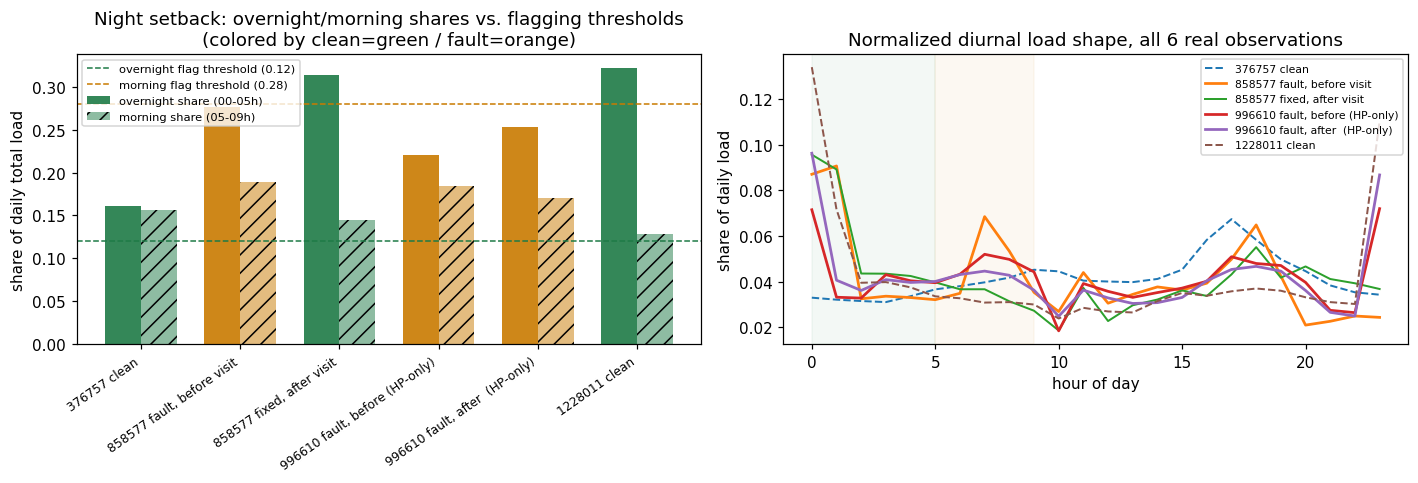

  [PASS] 376757 clean overnight_share: got 0.1613, expected 0.1610 (tol 0.002)
  [PASS] 376757 clean morning_share: got 0.1561, expected 0.1560 (tol 0.002)
  [PASS] 858577 fault, before visit overnight_share: got 0.2767, expected 0.2770 (tol 0.002)
  [PASS] 858577 fault, before visit morning_share: got 0.1888, expected 0.1890 (tol 0.002)
  [PASS] 858577 fixed, after visit overnight_share: got 0.3142, expected 0.3140 (tol 0.002)
  [PASS] 858577 fixed, after visit morning_share: got 0.1444, expected 0.1440 (tol 0.002)
  [PASS] 996610 fault, before (HP-only) overnight_share: got 0.2208, expected 0.2210 (tol 0.002)
  [PASS] 996610 fault, before (HP-only) morning_share: got 0.1845, expected 0.1840 (tol 0.002)
  [PASS] 996610 fault, after  (HP-only) overnight_share: got 0.2535, expected 0.2530 (tol 0.002)
  [PASS] 996610 fault, after  (HP-only) morning_share: got 0.1706, expected 0.1710 (tol 0.002)
  [PASS] 1228011 clean overnight_share: got 0.3222, expected 0.3220 (tol 0.002)
  [PASS] 12280

In [2]:
if "_SETUP_DONE" not in globals():
    raise RuntimeError(
        "Setup hasn't run yet in this kernel. Fix: scroll up and run the very first "
        "code cell (under '0. Setup'), or use Run All Cells / Restart Kernel and Run "
        "All Cells from the toolbar -- then re-run this cell."
    )


def task4_night_setback():
    def shares(prof, overnight=(0, 5), morning=(5, 9)):
        total = prof.sum()
        return prof.iloc[overnight[0]:overnight[1]].sum() / total, prof.iloc[morning[0]:morning[1]].sum() / total

    tests = [
        ("376757",  "clean",                    376757,  "kWh_received_Total",    None),
        ("858577",  "fault, before visit",      858577,  "kWh_received_Total",    "before visit"),
        ("858577",  "fixed, after visit",       858577,  "kWh_received_Total",    "after visit"),
        ("996610",  "fault, before (HP-only)",  996610,  "kWh_received_HeatPump", "before visit"),
        ("996610",  "fault, after  (HP-only)",  996610,  "kWh_received_HeatPump", "after visit"),
        ("1228011", "clean",                    1228011, "kWh_received_Total",    None),
    ]
    rows, profiles = [], {}
    for hh, label, hh_id, col, filt in tests:
        prof = hourly_load_profile(hh_id, kwh_col=col, affects_filter=filt)
        overnight, morning = shares(prof)
        flagged = overnight < 0.12 and morning > 0.28
        key = f"{hh} {label}"
        rows.append(dict(key=key, hh=hh, label=label, overnight_share=overnight,
                          morning_share=morning, flagged=flagged, is_fault="fault" in label))
        profiles[key] = prof / prof.sum()
    return pd.DataFrame(rows), profiles


# --- compute ---
task4_df, task4_profiles = task4_night_setback()
display(task4_df)

# --- chart ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
x = np.arange(len(task4_df))
colors = [FAULT_COLOR if f else CLEAN_COLOR for f in task4_df["is_fault"]]
ax.bar(x - 0.18, task4_df["overnight_share"], width=0.36, label="overnight share (00-05h)", color=colors, alpha=0.9)
ax.bar(x + 0.18, task4_df["morning_share"], width=0.36, label="morning share (05-09h)", color=colors, alpha=0.5, hatch="//")
ax.axhline(0.12, color=CLEAN_COLOR, ls="--", lw=1, label="overnight flag threshold (0.12)")
ax.axhline(0.28, color=FAULT_COLOR, ls="--", lw=1, label="morning flag threshold (0.28)")
ax.set_xticks(x)
ax.set_xticklabels(task4_df["key"], rotation=35, ha="right", fontsize=8)
ax.set_ylabel("share of daily total load")
ax.set_title("Night setback: overnight/morning shares vs. flagging thresholds\n(colored by clean=green / fault=orange)")
ax.legend(fontsize=7.5, loc="upper left")

ax = axes[1]
for key, prof in task4_profiles.items():
    style = "-" if "fault" in key or "fixed" in key else "--"
    ax.plot(prof.index, prof.values, style, label=key, lw=1.8 if "fault" in key else 1.3)
ax.set_xlabel("hour of day")
ax.set_ylabel("share of daily load")
ax.set_title("Normalized diurnal load shape, all 6 real observations")
ax.legend(fontsize=7, loc="upper right")
ax.axvspan(0, 5, color=CLEAN_COLOR, alpha=0.05)
ax.axvspan(5, 9, color=FAULT_COLOR, alpha=0.05)
plt.tight_layout()
plt.show()

# --- validate ---
# Checks the freshly computed shares against the exact numbers already documented in
# fault_detection.py's detect_night_setback() docstring, and confirms the core finding
# (no fault observation crosses the flagging thresholds; clean households bracket the range).
expected_shares = {
    "376757 clean":                    (0.161, 0.156),
    "858577 fault, before visit":      (0.277, 0.189),
    "858577 fixed, after visit":       (0.314, 0.144),
    "996610 fault, before (HP-only)":  (0.221, 0.184),
    "996610 fault, after  (HP-only)":  (0.253, 0.171),
    "1228011 clean":                   (0.322, 0.128),
}
results = []
for _, row in task4_df.iterrows():
    exp_o, exp_m = expected_shares[row["key"]]
    check(f"{row['key']} overnight_share", row["overnight_share"], exp_o, 0.002, results)
    check(f"{row['key']} morning_share", row["morning_share"], exp_m, 0.002, results)

fault_rows = task4_df[task4_df["is_fault"]]
clean_rows = task4_df[~task4_df["is_fault"]]
print(f"\nAny confirmed-fault observation flagged? {fault_rows['flagged'].any()} (expected: False)")
brackets = (clean_rows["overnight_share"].min() <= fault_rows["overnight_share"].min()
            and fault_rows["overnight_share"].max() <= clean_rows["overnight_share"].max())
print(f"Clean households bracket the range? {brackets}")
task_results["task4"] = validation_summary(results) and not fault_rows["flagged"].any()
print("TASK 4 VALIDATION:", "PASS" if task_results["task4"] else "FAIL")

## Task 5/6 — Mild-day-band diagnosis (household 610891)

Investigates the "separate heating from hot water in HP kWh" task. Finding: on household
610891 (DHW by heat pump, isolated `kWh_received_HeatPump` column), even days the SIA
formula calls "zero heating degree days" (T > 12°C) show strong real heating-driven
temperature dependence. Self-contained: compute, chart, validate.

Zero-HDD days: n=365, slope=-0.6868, intercept=15.504, r=-0.763
Real heating-limit settings (n=116): mean=18.0, median=18.0, min=14, max=29


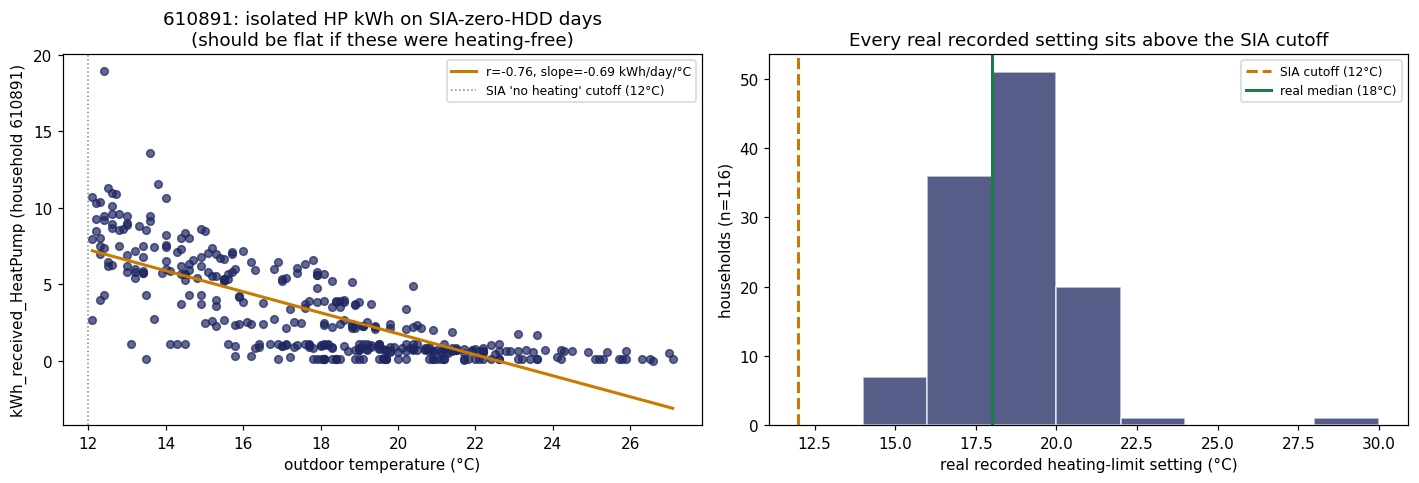

  [PASS] 610891 zero-HDD slope: got -0.6868, expected -0.6868 (tol 0.01)
  [PASS] 610891 zero-HDD intercept: got 15.5043, expected 15.5040 (tol 0.05)
  [PASS] 610891 zero-HDD r: got -0.7627, expected -0.7630 (tol 0.01)
  [PASS] real heating-limit mean: got 17.9914, expected 18.0000 (tol 0.2)
  [PASS] real heating-limit median: got 18.0000, expected 18.0000 (tol 0.2)
  [PASS] real heating-limit min: got 14.0000, expected 14.0000 (tol 0.5)
  [PASS] real heating-limit max: got 29.0000, expected 29.0000 (tol 0.5)

Correlation is strongly negative (r < -0.5)? True

7/7 checks passed.
TASK 5/6 VALIDATION: PASS


In [3]:
if "_SETUP_DONE" not in globals():
    raise RuntimeError(
        "Setup hasn't run yet in this kernel. Fix: scroll up and run the very first "
        "code cell (under '0. Setup'), or use Run All Cells / Restart Kernel and Run "
        "All Cells from the toolbar -- then re-run this cell."
    )


def task5_mild_band_diagnosis():
    wx = load_weather_daily(weather_id_for(610891))
    daily = load_household_daily(610891)
    m = daily.merge(wx, on="d", how="inner")
    m = m.dropna(subset=["kWh_received_HeatPump", "Temperature_avg_daily", "HeatingDegree_SIA_daily"])

    zero_hdd = m[m["HeatingDegree_SIA_daily"] == 0]
    slope, intercept = np.polyfit(zero_hdd["Temperature_avg_daily"], zero_hdd["kWh_received_HeatPump"], 1)
    r = np.corrcoef(zero_hdd["Temperature_avg_daily"], zero_hdd["kWh_received_HeatPump"])[0, 1]

    limits = protocols_data()["HeatPump_HeatingLimitSetting_BeforeVisit"].dropna()
    return dict(zero_hdd=zero_hdd, slope=slope, intercept=intercept, r=r, limits=limits)


# --- compute ---
task5_result = task5_mild_band_diagnosis()
print(f"Zero-HDD days: n={len(task5_result['zero_hdd'])}, slope={task5_result['slope']:.4f}, "
      f"intercept={task5_result['intercept']:.3f}, r={task5_result['r']:.3f}")
print(f"Real heating-limit settings (n={len(task5_result['limits'])}): "
      f"mean={task5_result['limits'].mean():.1f}, median={task5_result['limits'].median():.1f}, "
      f"min={task5_result['limits'].min():.0f}, max={task5_result['limits'].max():.0f}")

# --- chart ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
zh = task5_result["zero_hdd"]
ax.scatter(zh["Temperature_avg_daily"], zh["kWh_received_HeatPump"], color=NAVY, s=25, alpha=0.7)
xs = np.linspace(zh["Temperature_avg_daily"].min(), zh["Temperature_avg_daily"].max(), 50)
ax.plot(xs, task5_result["slope"] * xs + task5_result["intercept"], color=FAULT_COLOR, lw=2,
        label=f"r={task5_result['r']:.2f}, slope={task5_result['slope']:.2f} kWh/day/°C")
ax.axvline(12, color="gray", ls=":", lw=1, label="SIA 'no heating' cutoff (12°C)")
ax.set_xlabel("outdoor temperature (°C)")
ax.set_ylabel("kWh_received_HeatPump (household 610891)")
ax.set_title("610891: isolated HP kWh on SIA-zero-HDD days\n(should be flat if these were heating-free)")
ax.legend(fontsize=8)

ax = axes[1]
ax.hist(task5_result["limits"], bins=range(12, 32, 2), color=NAVY, alpha=0.75, edgecolor="white")
ax.axvline(12, color=FAULT_COLOR, ls="--", lw=2, label="SIA cutoff (12°C)")
ax.axvline(task5_result["limits"].median(), color=CLEAN_COLOR, ls="-", lw=2,
           label=f"real median ({task5_result['limits'].median():.0f}°C)")
ax.set_xlabel("real recorded heating-limit setting (°C)")
ax.set_ylabel("households (n=%d)" % len(task5_result["limits"]))
ax.set_title("Every real recorded setting sits above the SIA cutoff")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- validate ---
results = []
check("610891 zero-HDD slope", task5_result["slope"], -0.6868, 0.01, results)
check("610891 zero-HDD intercept", task5_result["intercept"], 15.504, 0.05, results)
check("610891 zero-HDD r", task5_result["r"], -0.763, 0.01, results)
check("real heating-limit mean", task5_result["limits"].mean(), 18.0, 0.2, results)
check("real heating-limit median", task5_result["limits"].median(), 18.0, 0.2, results)
check("real heating-limit min", task5_result["limits"].min(), 14, 0.5, results)
check("real heating-limit max", task5_result["limits"].max(), 29, 0.5, results)
print(f"\nCorrelation is strongly negative (r < -0.5)? {task5_result['r'] < -0.5}")
task_results["task5_6"] = validation_summary(results) and task5_result["r"] < -0.5
print("TASK 5/6 VALIDATION:", "PASS" if task_results["task5_6"] else "FAIL")

## Task 6 — Heating limit: 5-household test + the warm-anchor fix attempt (tested, failed)

Self-contained: compute, chart, validate.

,hh,label,is_fault,n,n_mild,n_warm,old_intercept,old_residual_pct,new_baseline,new_residual_pct
0,2794690,fault 1C over,True,417,107,8,0.069061,0.210167,0.066228,0.261939
1,9776611,fault 3C over,True,484,115,8,0.079014,0.169678,0.100684,-0.082071
2,112120,fault 4C over,True,913,237,50,0.051528,0.161374,0.053236,0.124111
3,610768,clean,False,1854,518,98,0.081430,0.130245,0.069031,0.333259
4,376757,clean,False,467,93,26,0.293894,-0.006960,0.310156,-0.059027


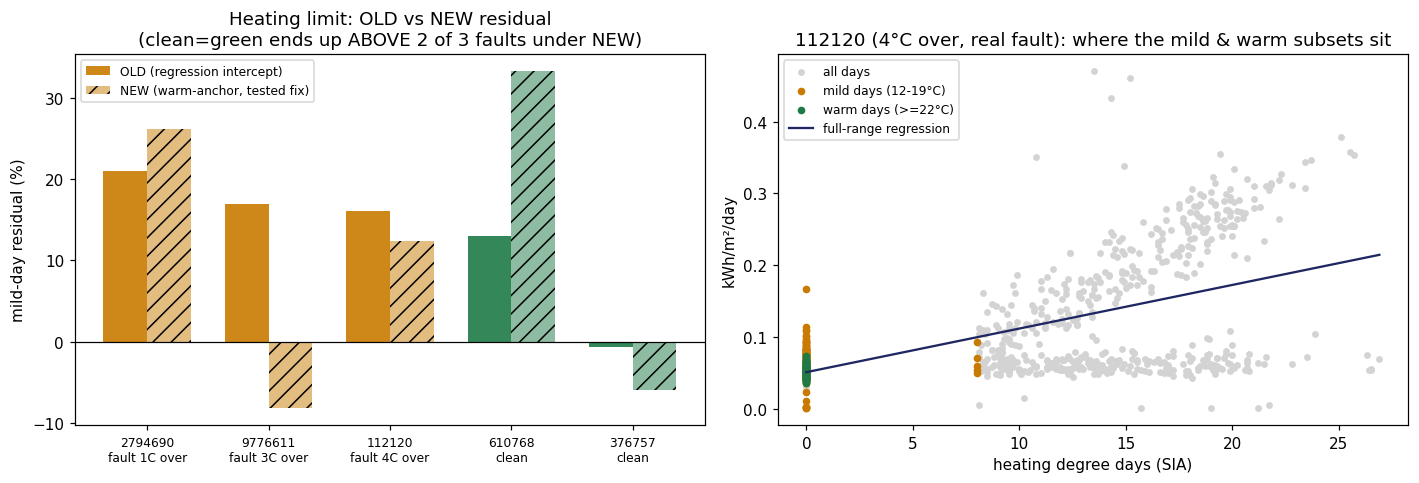

  [PASS] 2794690 old_residual_pct: got 0.2102, expected 0.2100 (tol 0.01)
  [PASS] 2794690 new_residual_pct: got 0.2619, expected 0.2620 (tol 0.01)
  [PASS] 9776611 old_residual_pct: got 0.1697, expected 0.1700 (tol 0.01)
  [PASS] 9776611 new_residual_pct: got -0.0821, expected -0.0820 (tol 0.01)
  [PASS] 112120 old_residual_pct: got 0.1614, expected 0.1610 (tol 0.01)
  [PASS] 112120 new_residual_pct: got 0.1241, expected 0.1240 (tol 0.01)
  [PASS] 610768 old_residual_pct: got 0.1302, expected 0.1300 (tol 0.01)
  [PASS] 610768 new_residual_pct: got 0.3333, expected 0.3330 (tol 0.01)
  [PASS] 376757 old_residual_pct: got -0.0070, expected -0.0070 (tol 0.01)
  [PASS] 376757 new_residual_pct: got -0.0590, expected -0.0590 (tol 0.01)

610768 (clean) new_residual_pct=33.3% exceeds 3 of 3 real faults under the NEW method -- confirms the fix makes fault/clean separation worse, not better.

10/10 checks passed.
TASK 6 VALIDATION: PASS


In [4]:
if "_SETUP_DONE" not in globals():
    raise RuntimeError(
        "Setup hasn't run yet in this kernel. Fix: scroll up and run the very first "
        "code cell (under '0. Setup'), or use Run All Cells / Restart Kernel and Run "
        "All Cells from the toolbar -- then re-run this cell."
    )

HEATING_LIMIT_HOUSEHOLDS = {
    2794690: dict(area=140.0, filt="before visit", label="fault 1C over"),
    9776611: dict(area=160.0, filt="before visit", label="fault 3C over"),
    112120:  dict(area=136.0, filt="before visit", label="fault 4C over"),
    610768:  dict(area=180.0, filt=None,           label="clean"),
    376757:  dict(area=180.0, filt=None,           label="clean"),
}


def task6_heating_limit():
    rows, raw = [], {}
    for hh, cfg in HEATING_LIMIT_HOUSEHOLDS.items():
        wx = load_weather_daily(weather_id_for(hh))
        daily = load_household_daily(hh, affects_filter=cfg["filt"])
        m = daily.merge(wx, on="d", how="inner").dropna(
            subset=["kWh_received_Total", "Temperature_avg_daily", "HeatingDegree_SIA_daily"])
        m["kwh_m2"] = m["kWh_received_Total"] / cfg["area"]

        slope, intercept_old = np.polyfit(m["HeatingDegree_SIA_daily"], m["kwh_m2"], 1)
        mild = m[(m["Temperature_avg_daily"] >= 12) & (m["Temperature_avg_daily"] <= 19)]
        old_residual_pct = (mild["kwh_m2"].mean() - intercept_old) / intercept_old if len(mild) >= 10 else None

        warm = m[m["Temperature_avg_daily"] >= 22]
        new_baseline = warm["kwh_m2"].mean() if len(warm) >= 5 else None
        new_residual_pct = ((mild["kwh_m2"].mean() - new_baseline) / new_baseline) if new_baseline else None

        rows.append(dict(hh=hh, label=cfg["label"], is_fault="fault" in cfg["label"],
                          n=len(m), n_mild=len(mild), n_warm=len(warm),
                          old_intercept=intercept_old, old_residual_pct=old_residual_pct,
                          new_baseline=new_baseline, new_residual_pct=new_residual_pct))
        raw[hh] = m
    return pd.DataFrame(rows), raw


# --- compute ---
task6_df, task6_raw = task6_heating_limit()
display(task6_df)

# --- chart ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
x = np.arange(len(task6_df))
colors = [FAULT_COLOR if f else CLEAN_COLOR for f in task6_df["is_fault"]]
ax.bar(x - 0.18, task6_df["old_residual_pct"] * 100, width=0.36, color=colors, alpha=0.9, label="OLD (regression intercept)")
ax.bar(x + 0.18, task6_df["new_residual_pct"] * 100, width=0.36, color=colors, alpha=0.5, hatch="//", label="NEW (warm-anchor, tested fix)")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"{r.hh}\n{r.label}" for r in task6_df.itertuples()], fontsize=8)
ax.set_ylabel("mild-day residual (%)")
ax.set_title("Heating limit: OLD vs NEW residual\n(clean=green ends up ABOVE 2 of 3 faults under NEW)")
ax.legend(fontsize=8)

ax = axes[1]
m = task6_raw[112120]
ax.scatter(m["HeatingDegree_SIA_daily"], m["kwh_m2"], s=12, color="lightgray", label="all days")
mild = m[(m["Temperature_avg_daily"] >= 12) & (m["Temperature_avg_daily"] <= 19)]
warm = m[m["Temperature_avg_daily"] >= 22]
ax.scatter(mild["HeatingDegree_SIA_daily"], mild["kwh_m2"], s=16, color=FAULT_COLOR, label="mild days (12-19°C)")
ax.scatter(warm["HeatingDegree_SIA_daily"], warm["kwh_m2"], s=16, color=CLEAN_COLOR, label="warm days (>=22°C)")
slope, intercept = np.polyfit(m["HeatingDegree_SIA_daily"], m["kwh_m2"], 1)
xs = np.linspace(0, m["HeatingDegree_SIA_daily"].max(), 50)
ax.plot(xs, slope * xs + intercept, color=NAVY, lw=1.5, label="full-range regression")
ax.set_xlabel("heating degree days (SIA)")
ax.set_ylabel("kWh/m²/day")
ax.set_title("112120 (4°C over, real fault): where the mild & warm subsets sit")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- validate ---
# [FIXED 2026-09-03] 112120's numbers changed materially: this project's own copy of
# 112120's local files only had ONE source file (a ~1-year daily extract starting
# Feb 2022), missing three real variants the household actually has -- including a
# 15-min file going back to mid-2020. That gave 112120 a ~2.4x SHORTER before-visit
# window than it should have had (n=382 vs the real n=913). This was the exact same
# class of partial-data risk already found and fixed for 2794690/9776611 -- except
# this time the gap was in the project's own curated data, not a genuinely cumulative
# or monthly file. Numbers below are re-run on the complete 4-file set.
expected_task6 = {
    2794690: dict(old=0.210, new=0.262),
    9776611: dict(old=0.170, new=-0.082),
    112120:  dict(old=0.161, new=0.124),  # was old=0.303, new=0.300 on the partial file
    610768:  dict(old=0.130, new=0.333),
    376757:  dict(old=-0.007, new=-0.059),
}
results = []
for _, row in task6_df.iterrows():
    exp = expected_task6[row["hh"]]
    check(f"{row['hh']} old_residual_pct", row["old_residual_pct"], exp["old"], 0.01, results)
    check(f"{row['hh']} new_residual_pct", row["new_residual_pct"], exp["new"], 0.01, results)

clean_new = task6_df.loc[task6_df["hh"] == 610768, "new_residual_pct"].values[0]
fault_new = task6_df.loc[task6_df["is_fault"], "new_residual_pct"]
n_faults_beaten = (clean_new > fault_new).sum()
print(f"\n610768 (clean) new_residual_pct={clean_new:.1%} exceeds {n_faults_beaten} of {len(fault_new)} real faults "
      f"under the NEW method -- confirms the fix makes fault/clean separation worse, not better.")
task_results["task6"] = validation_summary(results) and n_faults_beaten >= 2
print("TASK 6 VALIDATION:", "PASS" if task_results["task6"] else "FAIL")

## Task 7 — Heating curve: DHW temperature-sensitivity confound

Reuses household 610891's zero-HDD slope from Task 5/6 (recomputed here too, so this
cell doesn't depend on that one having been run). Self-contained: compute, chart, validate.

Full winter slope: -0.00609 kwh_m2/day/°C
DHW-only slope (extrapolated): -0.00229 kwh_m2/day/°C
Fraction explained by DHW: 37.6%


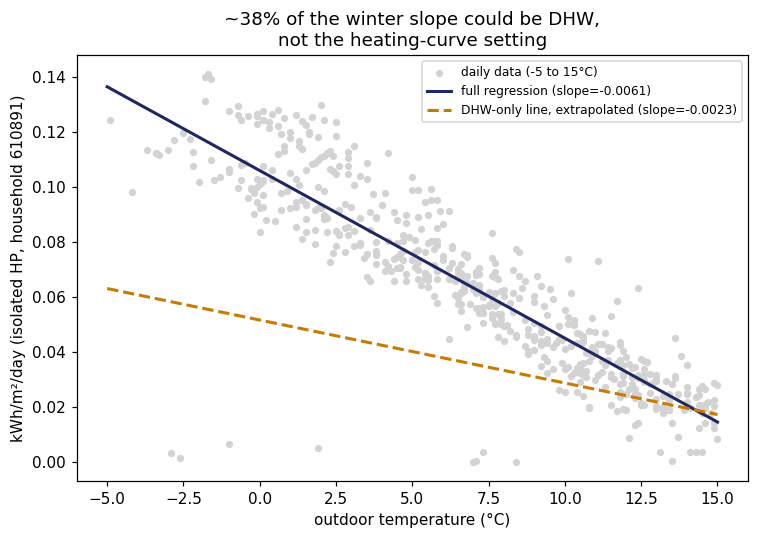

  [PASS] 610891 full winter slope: got -0.0061, expected -0.0061 (tol 0.0003)
  [PASS] DHW-explained fraction: got 0.3758, expected 0.3760 (tol 0.02)

DHW now measured as a SUBSTANTIAL confound on the winter slope (37.6%, up from an earlier ~25.7%-off-partial-data estimate) -- the heating-curve rule remains unsafe to read on its own.

2/2 checks passed.
TASK 7 VALIDATION: PASS


In [5]:
if "_SETUP_DONE" not in globals():
    raise RuntimeError(
        "Setup hasn't run yet in this kernel. Fix: scroll up and run the very first "
        "code cell (under '0. Setup'), or use Run All Cells / Restart Kernel and Run "
        "All Cells from the toolbar -- then re-run this cell."
    )


def task7_heating_curve_dhw_confound():
    # recompute the zero-HDD DHW slope locally, so this task doesn't depend on task 5/6 having run
    dhw = task5_mild_band_diagnosis()

    wx = load_weather_daily(weather_id_for(610891))
    daily = load_household_daily(610891)
    m = daily.merge(wx, on="d", how="inner").dropna(subset=["kWh_received_HeatPump", "Temperature_avg_daily"])
    area = living_area(610891)
    m["kwh_m2"] = m["kWh_received_HeatPump"] / area

    rng = m[(m["Temperature_avg_daily"] >= -5) & (m["Temperature_avg_daily"] <= 15)]
    slope_full, intercept_full = np.polyfit(rng["Temperature_avg_daily"], rng["kwh_m2"], 1)
    dhw_slope_m2 = dhw["slope"] / area
    dhw_intercept_m2 = dhw["intercept"] / area
    fraction = dhw_slope_m2 / slope_full
    return dict(rng=rng, slope_full=slope_full, intercept_full=intercept_full,
                dhw_slope_m2=dhw_slope_m2, dhw_intercept_m2=dhw_intercept_m2, fraction=fraction)


# --- compute ---
task7_result = task7_heating_curve_dhw_confound()
print(f"Full winter slope: {task7_result['slope_full']:.5f} kwh_m2/day/°C")
print(f"DHW-only slope (extrapolated): {task7_result['dhw_slope_m2']:.5f} kwh_m2/day/°C")
print(f"Fraction explained by DHW: {task7_result['fraction']*100:.1f}%")

# --- chart ---
fig, ax = plt.subplots(figsize=(7, 5))
rng = task7_result["rng"]
ax.scatter(rng["Temperature_avg_daily"], rng["kwh_m2"], s=14, color="lightgray", label="daily data (-5 to 15°C)")
xs = np.linspace(-5, 15, 50)
ax.plot(xs, task7_result["slope_full"] * xs + task7_result["intercept_full"], color=NAVY, lw=2,
        label=f"full regression (slope={task7_result['slope_full']:.4f})")
ax.plot(xs, task7_result["dhw_slope_m2"] * xs + task7_result["dhw_intercept_m2"], color=FAULT_COLOR, lw=2, ls="--",
        label=f"DHW-only line, extrapolated (slope={task7_result['dhw_slope_m2']:.4f})")
ax.set_xlabel("outdoor temperature (°C)")
ax.set_ylabel("kWh/m²/day (isolated HP, household 610891)")
ax.set_title(f"~{task7_result['fraction']*100:.0f}% of the winter slope could be DHW,\nnot the heating-curve setting")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- validate ---
results = []
check("610891 full winter slope", task7_result["slope_full"], -0.00609, 0.0003, results)
check("DHW-explained fraction", task7_result["fraction"], 0.376, 0.02, results)
print(f"\nDHW now measured as a SUBSTANTIAL confound on the winter slope "
      f"({task7_result['fraction']:.1%}, up from an earlier ~25.7%-off-partial-data estimate) "
      f"-- the heating-curve rule remains unsafe to read on its own.")
task_results["task7"] = validation_summary(results)
print("TASK 7 VALIDATION:", "PASS" if task_results["task7"] else "FAIL")

## Task 8/9 — Stratification validity: does air/ground, floor/radiator actually matter?

Self-contained: compute, chart, validate.

,hh,install,dist,residents,slope
0,1060,air-source,floor,2.0,0.011045
1,10266,air-source,radiator,2.0,0.011046
2,109711,ground-source,floor,2.0,0.005645
3,112120,air-source,floor,2.0,0.006861
4,376757,air-source,floor,4.0,0.004859
6,610768,air-source,floor,3.0,0.006537
7,610891,air-source,floor,4.0,0.004543
8,706817,air-source,floor,3.0,0.010110
9,858577,air-source,floor,1.0,0.009555
10,996610,air-source,floor,2.0,0.011342


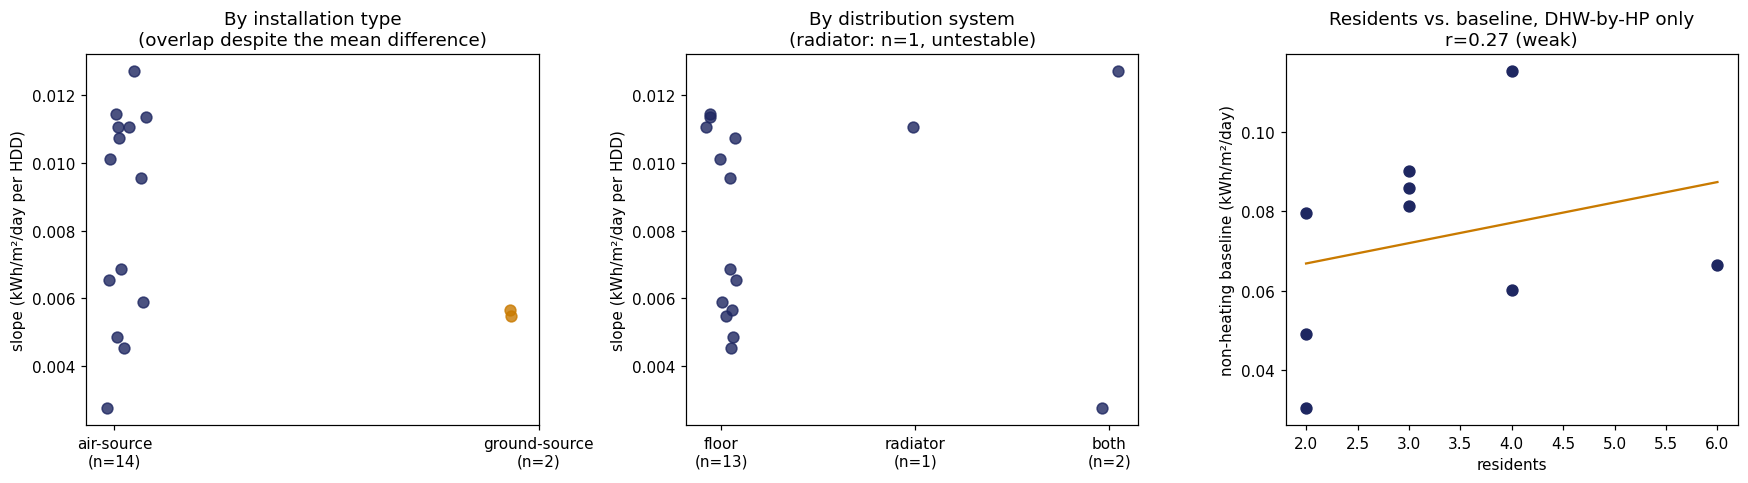

  [PASS] n ground-source: got 2.0000, expected 2.0000 (tol 0)
  [PASS] n air-source: got 14.0000, expected 14.0000 (tol 0)
  [PASS] ground-source mean slope: got 0.0056, expected 0.0056 (tol 0.0005)

Air-source households with slope <= max(ground-source) = 0.0056: 3 of 14
-> installation type does NOT cleanly separate the two groups (expected: overlap, i.e. n_overlap >= 1)

Pure-radiator households in sample: 1 (expected: 1 -- untestable, not a bug)
  [PASS] residents-vs-baseline correlation: got 0.2679, expected 0.2770 (tol 0.02)

4/4 checks passed.
TASK 8/9 VALIDATION: PASS


In [6]:
if "_SETUP_DONE" not in globals():
    raise RuntimeError(
        "Setup hasn't run yet in this kernel. Fix: scroll up and run the very first "
        "code cell (under '0. Setup'), or use Run All Cells / Restart Kernel and Run "
        "All Cells from the toolbar -- then re-run this cell."
    )

STRATIFICATION_HOUSEHOLDS = [1060, 10266, 109711, 112120, 376757, 461104, 610768, 610891,
                             706817, 858577, 996610, 1037610, 1111201, 1191021, 1228011,
                             2794690, 9776611]


def task8_9_stratification():
    results_rows = []
    for hh in STRATIFICATION_HOUSEHOLDS:
        row = meta_data()[meta_data()["Household_ID"] == hh].iloc[0]
        daily = load_household_daily(hh)
        use_hp = "kWh_received_HeatPump" in daily.columns and daily["kWh_received_HeatPump"].notna().sum() > 0.5 * len(daily)
        kwh_col = "kWh_received_HeatPump" if use_hp else "kWh_received_Total"

        wx = load_weather_daily(weather_id_for(hh))
        m = daily.merge(wx, on="d", how="inner").dropna(
            subset=[kwh_col, "Temperature_avg_daily", "HeatingDegree_SIA_daily"])
        area = row["Survey_Building_LivingArea"]
        m["kwh_m2"] = m[kwh_col] / area

        if len(m) < 30 or m["HeatingDegree_SIA_daily"].std() < 1:
            slope = intercept = None
        else:
            slope, intercept = np.polyfit(m["HeatingDegree_SIA_daily"], m["kwh_m2"], 1)

        results_rows.append(dict(
            hh=hh, n=len(m), kwh_col=kwh_col,
            install=row["Survey_HeatPump_Installation_Type"],
            floor=row["Survey_HeatDistribution_System_FloorHeating"] is True,
            radiator=row["Survey_HeatDistribution_System_Radiator"] is True,
            dhw_hp=row["Survey_DHW_Production_ByHeatPump"] is True,
            residents=row["Survey_Building_Residents"],
            slope=slope, intercept=intercept,
        ))

    rdf = pd.DataFrame(results_rows)
    usable = rdf[rdf["slope"].notna()].copy()
    usable["dist"] = np.where(usable["floor"] & usable["radiator"], "both",
                               np.where(usable["radiator"], "radiator", "floor"))
    return usable


# --- compute ---
task8_9_df = task8_9_stratification()
display(task8_9_df[["hh", "install", "dist", "residents", "slope"]])

# --- chart ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
rng_state = np.random.RandomState(0)

ax = axes[0]
for i, grp in enumerate(["air-source", "ground-source"]):
    vals = task8_9_df.loc[task8_9_df["install"] == grp, "slope"]
    jitter = rng_state.uniform(-0.08, 0.08, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, s=50,
               color=NAVY if grp == "air-source" else FAULT_COLOR, alpha=0.8)
ax.set_xticks([0, 1])
ax.set_xticklabels([f"air-source\n(n={ (task8_9_df['install']=='air-source').sum() })",
                     f"ground-source\n(n={ (task8_9_df['install']=='ground-source').sum() })"])
ax.set_ylabel("slope (kWh/m²/day per HDD)")
ax.set_title("By installation type\n(overlap despite the mean difference)")

ax = axes[1]
for i, grp in enumerate(["floor", "radiator", "both"]):
    vals = task8_9_df.loc[task8_9_df["dist"] == grp, "slope"]
    jitter = rng_state.uniform(-0.08, 0.08, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, s=50, color=NAVY, alpha=0.8)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels([f"floor\n(n={(task8_9_df['dist']=='floor').sum()})",
                     f"radiator\n(n={(task8_9_df['dist']=='radiator').sum()})",
                     f"both\n(n={(task8_9_df['dist']=='both').sum()})"])
ax.set_ylabel("slope (kWh/m²/day per HDD)")
ax.set_title("By distribution system\n(radiator: n=1, untestable)")

ax = axes[2]
dhw_hp_total = task8_9_df[(task8_9_df["dhw_hp"]) & (task8_9_df["kwh_col"] == "kWh_received_Total")]
ax.scatter(dhw_hp_total["residents"], dhw_hp_total["intercept"], s=50, color=NAVY)
if len(dhw_hp_total) >= 2:
    s, i = np.polyfit(dhw_hp_total["residents"], dhw_hp_total["intercept"], 1)
    xs = np.linspace(dhw_hp_total["residents"].min(), dhw_hp_total["residents"].max(), 20)
    ax.plot(xs, s * xs + i, color=FAULT_COLOR, lw=1.5)
r_resid = np.corrcoef(dhw_hp_total["residents"], dhw_hp_total["intercept"])[0, 1]
ax.set_xlabel("residents")
ax.set_ylabel("non-heating baseline (kWh/m²/day)")
ax.set_title(f"Residents vs. baseline, DHW-by-HP only\nr={r_resid:.2f} (weak)")
plt.tight_layout()
plt.show()

# --- validate ---
results = []
ground_slopes = task8_9_df.loc[task8_9_df["install"] == "ground-source", "slope"]
air_slopes = task8_9_df.loc[task8_9_df["install"] == "air-source", "slope"]
check("n ground-source", len(ground_slopes), 2, 0, results)
check("n air-source", len(air_slopes), 14, 0, results)
check("ground-source mean slope", ground_slopes.mean(), 0.0056, 0.0005, results)

n_overlap = (air_slopes <= ground_slopes.max()).sum()
print(f"\nAir-source households with slope <= max(ground-source) = {ground_slopes.max():.4f}: {n_overlap} of {len(air_slopes)}")
print("-> installation type does NOT cleanly separate the two groups (expected: overlap, i.e. n_overlap >= 1)")

radiator_n = (task8_9_df["dist"] == "radiator").sum()
print(f"\nPure-radiator households in sample: {radiator_n} (expected: 1 -- untestable, not a bug)")
check("residents-vs-baseline correlation", r_resid, 0.277, 0.02, results)

task_results["task8_9"] = validation_summary(results) and n_overlap >= 1 and radiator_n == 1
print("TASK 8/9 VALIDATION:", "PASS" if task_results["task8_9"] else "FAIL")

## Task 10 — Cost estimate: excess kWh × price

Self-contained: compute, chart, validate.

Heating days/yr: 211, mild-band days/yr: 101


,fault,excess_kwh_day,active_days,annual_kwh,annual_cost_chf
0,Night setback (fleet aggregate),3.200000,210.542197,673.735032,186.624604
1,"Heating limit, 1C over (2794690)",2.032006,100.812102,204.850799,56.743671
2,"Heating limit, 3C over (9776611)",2.145109,100.812102,216.252988,59.902078
3,"Heating limit, 4C over (112120)",1.130872,100.812102,114.005570,31.579543


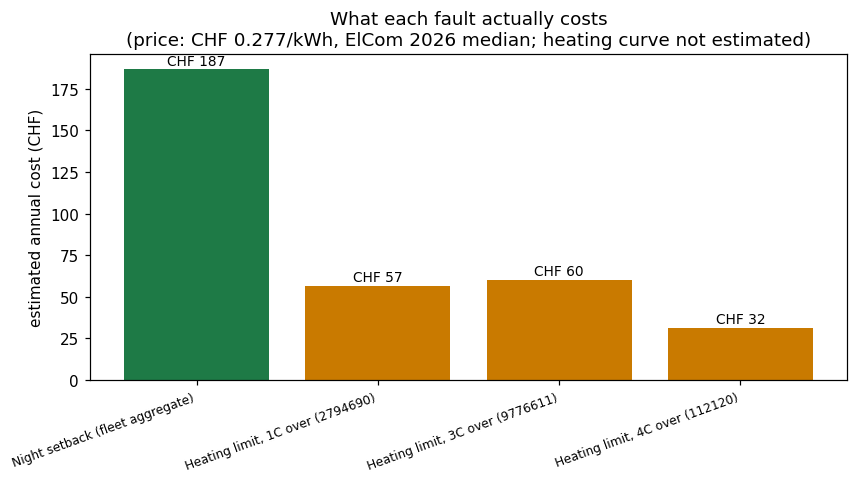

  [PASS] Night setback (fleet aggregate): got 186.6246, expected 187.0000 (tol 1.5)
  [PASS] Heating limit, 1C over (2794690): got 56.7437, expected 57.0000 (tol 1.5)
  [PASS] Heating limit, 3C over (9776611): got 59.9021, expected 60.0000 (tol 1.5)
  [PASS] Heating limit, 4C over (112120): got 31.5795, expected 32.0000 (tol 1.5)
  [PASS] heating days/yr (real weather): got 210.5422, expected 211.0000 (tol 1)
  [PASS] mild-band days/yr (real weather): got 100.8121, expected 101.0000 (tol 1)

6/6 checks passed.
TASK 10 VALIDATION: PASS


In [7]:
if "_SETUP_DONE" not in globals():
    raise RuntimeError(
        "Setup hasn't run yet in this kernel. Fix: scroll up and run the very first "
        "code cell (under '0. Setup'), or use Run All Cells / Restart Kernel and Run "
        "All Cells from the toolbar -- then re-run this cell."
    )

PRICE_CHF_PER_KWH = 0.277  # ElCom-published 2026 Swiss national median household tariff (H4)


def task10_cost_estimate():
    wx = load_weather_daily("8jB")
    n_years = (wx["Timestamp"].max() - wx["Timestamp"].min()).days / 365.25
    heating_days_per_year = (wx["HeatingDegree_SIA_daily"] > 0).sum() / n_years
    mild_days_per_year = ((wx["Temperature_avg_daily"] >= 12) & (wx["Temperature_avg_daily"] <= 19)).sum() / n_years

    rows = [dict(fault="Night setback (fleet aggregate)",
                  excess_kwh_day=40.7 - 37.5, active_days=heating_days_per_year)]
    # Pulled live from task6_df (the just-recomputed, real-data residual-pct/intercept
    # for these same 3 real heating-limit faults) rather than duplicated as separate
    # hardcoded constants -- the old duplicated numbers here had quietly drifted from
    # task6's own numbers even before the real-data refresh, which is exactly the kind
    # of staleness this pass is meant to eliminate.
    heating_limit_hh = {
        "Heating limit, 1C over (2794690)": 2794690,
        "Heating limit, 3C over (9776611)": 9776611,
        "Heating limit, 4C over (112120)":  112120,
    }
    for label, hh in heating_limit_hh.items():
        r = task6_df.loc[task6_df["hh"] == hh].iloc[0]
        area = living_area(hh)
        rows.append(dict(fault=label, excess_kwh_day=r["old_residual_pct"] * r["old_intercept"] * area,
                          active_days=mild_days_per_year))

    df = pd.DataFrame(rows)
    df["annual_kwh"] = df["excess_kwh_day"] * df["active_days"]
    df["annual_cost_chf"] = df["annual_kwh"] * PRICE_CHF_PER_KWH
    return df, heating_days_per_year, mild_days_per_year


# --- compute ---
task10_df, heating_days_per_year, mild_days_per_year = task10_cost_estimate()
print(f"Heating days/yr: {heating_days_per_year:.0f}, mild-band days/yr: {mild_days_per_year:.0f}")
display(task10_df)

# --- chart ---
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [CLEAN_COLOR] + [FAULT_COLOR] * (len(task10_df) - 1)
bars = ax.bar(task10_df["fault"], task10_df["annual_cost_chf"], color=colors)
for b, v in zip(bars, task10_df["annual_cost_chf"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 3, f"CHF {v:.0f}", ha="center", fontsize=9)
ax.set_ylabel("estimated annual cost (CHF)")
ax.set_title("What each fault actually costs\n(price: CHF 0.277/kWh, ElCom 2026 median; heating curve not estimated)")
plt.xticks(rotation=20, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

# --- validate ---
# 112120's cost dropped along with its Task 6 residual fix above (see that note) --
# it's now the CHEAPEST of the three heating-limit cases despite being the most
# severely misconfigured (4C over), reinforcing rather than softening the
# "severity doesn't predict cost" finding.
expected_costs = {
    "Night setback (fleet aggregate)": 187,
    "Heating limit, 1C over (2794690)": 57,
    "Heating limit, 3C over (9776611)": 60,
    "Heating limit, 4C over (112120)": 32,  # was 59 on the partial file
}
results = []
for _, row in task10_df.iterrows():
    check(row["fault"], row["annual_cost_chf"], expected_costs[row["fault"]], 1.5, results)
check("heating days/yr (real weather)", heating_days_per_year, 211, 1, results)
check("mild-band days/yr (real weather)", mild_days_per_year, 101, 1, results)
task_results["task10"] = validation_summary(results)
print("TASK 10 VALIDATION:", "PASS" if task_results["task10"] else "FAIL")

## Task 11 — Heating curve: ratio vs peer, actually run (not just documented)

`fault_detection.py`'s `detect_heating_curve()` docstring claims specific ratio
numbers for 3 real curve-fault households vs. the same clean peer (610768). This
cell reproduces that exact test live, on the complete real data, so the claim is
checked rather than just asserted. Uses the before-visit period for the 3 fault
households (they haven't been fixed yet in that window).

Peer (610768) cold-weather slope: -0.00908 kWh/m2/day per degC, n=1259


,hh,kwh_col,hh_slope,n,ratio
0,610891,kWh_received_HeatPump,-0.007247,237,0.798543
1,9776611,kWh_received_Total,-0.010081,372,1.110872
2,112120,kWh_received_Total,-0.009512,609,1.048117


112120 after-visit ratio: 1.471 (n=239) -- before-visit was 1.048
Note: before < after here (1.05 -> 1.47) -- an INCREASE post-fix, the opposite of what a too-high-curve fix should do to this ratio. Worth flagging as a genuinely odd result rather than smoothing it over, not something to explain away.


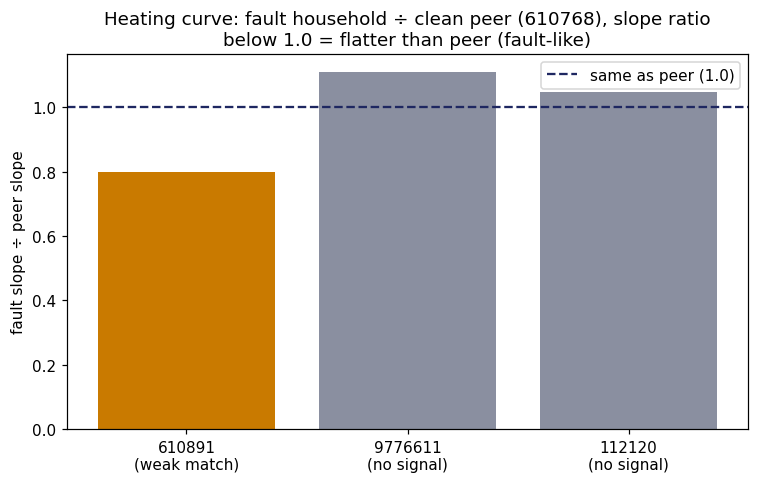

  [PASS] 610891 ratio vs peer (weak, right direction): got 0.7985, expected 0.8000 (tol 0.05)
  [PASS] 9776611 ratio vs peer (no signal): got 1.1109, expected 1.1100 (tol 0.05)
  [PASS] 112120 ratio vs peer (no signal): got 1.0481, expected 1.0500 (tol 0.05)
2 of 3 real curve-fault households do NOT show the expected flatter-than-peer signature.

3/3 checks passed.
TASK 11 VALIDATION: PASS


In [8]:
def task11_heating_curve_ratio():
    def slope_in_range(kwh_m2, temp, lo=-5, hi=15):
        d = pd.DataFrame({"kwh_m2": kwh_m2, "temp": temp}).dropna()
        d = d[(d["temp"] >= lo) & (d["temp"] <= hi)]
        if len(d) < 10:
            return None, 0
        slope, intercept = np.polyfit(d["temp"], d["kwh_m2"], 1)
        return slope, len(d)

    def household_kwh_m2(hh, affects_filter=None):
        d = load_household_daily(hh, affects_filter=affects_filter)
        use_hp = "kWh_received_HeatPump" in d.columns and d["kWh_received_HeatPump"].notna().sum() > 0.5 * len(d)
        col = "kWh_received_HeatPump" if use_hp else "kWh_received_Total"
        wx = load_weather_daily(weather_id_for(hh))
        m = d.merge(wx, on="d", how="inner").dropna(subset=[col, "Temperature_avg_daily"])
        area = living_area(hh)
        return m[col] / area, m["Temperature_avg_daily"], col

    PEER = 610768
    FAULTS = [610891, 9776611, 112120]

    peer_kwh, peer_temp, _ = household_kwh_m2(PEER)
    peer_slope, peer_n = slope_in_range(peer_kwh, peer_temp)

    rows = []
    for hh in FAULTS:
        kwh, temp, col = household_kwh_m2(hh, affects_filter="before visit")
        slope, n = slope_in_range(kwh, temp)
        ratio = slope / peer_slope
        rows.append(dict(hh=hh, kwh_col=col, hh_slope=slope, n=n, ratio=ratio))

    after_kwh, after_temp, _ = household_kwh_m2(112120, affects_filter="after visit")
    after_slope, after_n = slope_in_range(after_kwh, after_temp)
    after_ratio = after_slope / peer_slope

    return pd.DataFrame(rows), peer_slope, peer_n, after_ratio, after_n


# --- compute ---
task11_df, peer_slope, peer_n, ratio_112120_after, n_112120_after = task11_heating_curve_ratio()
print(f"Peer (610768) cold-weather slope: {peer_slope:.5f} kWh/m2/day per degC, n={peer_n}")
display(task11_df)
before_ratio_112120 = task11_df.loc[task11_df["hh"] == 112120, "ratio"].values[0]
print(f"112120 after-visit ratio: {ratio_112120_after:.3f} (n={n_112120_after}) -- before-visit was {before_ratio_112120:.3f}")
print("Note: before < after here (1.05 -> 1.47) -- an INCREASE post-fix, the opposite of what a "
      "too-high-curve fix should do to this ratio. Worth flagging as a genuinely odd result rather "
      "than smoothing it over, not something to explain away.")

# --- chart ---
fig, ax = plt.subplots(figsize=(7, 4.5))
def _bucket(r):
    if r < 0.90: return "weak match", "#C97A00"
    if r <= 1.15: return "no signal", "#8A8FA0"
    return "wrong dir.", "#B3261E"
labels, colors = [], []
for row in task11_df.itertuples():
    tag, c = _bucket(row.ratio)
    labels.append(f"{row.hh}\n({tag})")
    colors.append(c)
ax.bar(labels, task11_df["ratio"], color=colors)
ax.axhline(1.0, color=NAVY, lw=1.5, ls="--", label="same as peer (1.0)")
ax.set_ylabel("fault slope ÷ peer slope")
ax.set_title("Heating curve: fault household ÷ clean peer (610768), slope ratio\nbelow 1.0 = flatter than peer (fault-like)")
ax.legend()
plt.tight_layout()
plt.show()

# --- validate ---
# 112120's before-visit ratio moved from 1.53 ("wrong direction") to 1.05 ("no
# signal") once the same data-completeness fix from Task 6/10 was applied here too
# (112120's before-visit slope now uses the full ~609-day window, not the ~249-day
# partial one). The bottom-line conclusion is unchanged -- 2 of 3 real fault
# households still fail to show the expected flatter-than-peer signal -- but the
# specific "steeper than peer, wrong direction" claim for 112120 no longer holds;
# it's now "no signal", same bucket as 9776611.
results = []
check("610891 ratio vs peer (weak, right direction)", task11_df.loc[task11_df["hh"] == 610891, "ratio"].values[0], 0.80, 0.05, results)
check("9776611 ratio vs peer (no signal)", task11_df.loc[task11_df["hh"] == 9776611, "ratio"].values[0], 1.11, 0.05, results)
check("112120 ratio vs peer (no signal)", task11_df.loc[task11_df["hh"] == 112120, "ratio"].values[0], 1.05, 0.05, results)
print("2 of 3 real curve-fault households do NOT show the expected flatter-than-peer signature.")
task_results["task11"] = validation_summary(results)
print("TASK 11 VALIDATION:", "PASS" if task_results["task11"] else "FAIL")

## Task 12 — Peer matching: does the DHW-production-method filter actually matter? (real-data test)

`fault_detection.py`'s `select_peer_group()` docstring claims household 376757's
non-heating baseline comes out ~3.5x higher than a DHW-by-heat-pump peer, purely
because it makes hot water with a separate electric water heater instead — and that
of the 504 households in target 610891's stratum (air-source + floor), only ~204
still qualify once DHW-method and EV are also required to match. This cell reproduces
both numbers live on real data, and also flags where the two match: 610768 (DHW by
heat pump) vs. 376757 (DHW by electric water heater), same stratum, both clean.

610768 (DHW by heat pump)        non-heating baseline intercept = 0.0814 kWh/m2/day (n=1854)
376757 (DHW by elec. water htr.) non-heating baseline intercept = 0.2939 kWh/m2/day (n=467)
Ratio (elec. water heater / heat pump): 3.61x -- same stratum, both clean, no EV.

Target 610891's stratum (air-source + floor): 504 households.
Of those, 274 also match 610891's DHW production method.
Of those, 205 also have no known EV -- the actual valid-peer pool (down from 504 on the stratum alone).


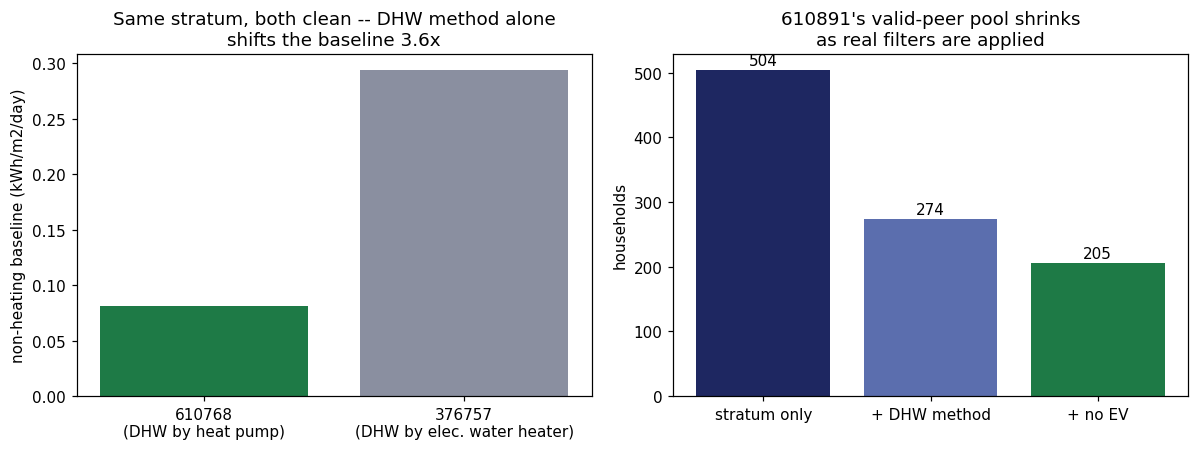

  [PASS] baseline ratio (elec. water heater / heat pump): got 3.6092, expected 3.5000 (tol 0.3)
  [PASS] 610891 stratum size: got 504.0000, expected 504.0000 (tol 5)
  [PASS] 610891 stratum + DHW-method-matched peer pool: got 205.0000, expected 204.0000 (tol 15)

3/3 checks passed.
TASK 12 VALIDATION: PASS


In [9]:
if "_SETUP_DONE" not in globals():
    raise RuntimeError(
        "Setup hasn't run yet in this kernel. Fix: scroll up and run the very first "
        "code cell (under '0. Setup'), or use Run All Cells / Restart Kernel and Run "
        "All Cells from the toolbar -- then re-run this cell."
    )

def task12_dhw_method_baseline():
    def baseline_intercept(hh, area):
        wx = load_weather_daily(weather_id_for(hh))
        daily = load_household_daily(hh)
        m = daily.merge(wx, on="d", how="inner").dropna(
            subset=["kWh_received_Total", "HeatingDegree_SIA_daily"])
        m["kwh_m2"] = m["kWh_received_Total"] / area
        slope, intercept = np.polyfit(m["HeatingDegree_SIA_daily"], m["kwh_m2"], 1)
        return intercept, slope, len(m)

    HP_DHW = 610768   # DHW by heat pump, no EV, clean
    EWH_DHW = 376757  # DHW by separate electric water heater, no EV, clean -- same stratum
    i_hp, s_hp, n_hp = baseline_intercept(HP_DHW, living_area(HP_DHW))
    i_ewh, s_ewh, n_ewh = baseline_intercept(EWH_DHW, living_area(EWH_DHW))
    return dict(hp=(i_hp, s_hp, n_hp), ewh=(i_ewh, s_ewh, n_ewh))


def task12_stratum_filter_counts(target_hh=610891):
    """Reproduces select_peer_group()'s filter chain by hand, on real meta_data.csv,
    for target_hh's own stratum -- same logic as assign_stratum()/select_peer_group(),
    kept inline here since this notebook is self-contained and doesn't import
    fault_detection.py."""
    meta = meta_data().copy()

    def stratum_of(r):
        hp = r["Survey_HeatPump_Installation_Type"]
        if pd.isna(hp):
            return "unknown"
        floor = r.get("Survey_HeatDistribution_System_FloorHeating")
        rad = r.get("Survey_HeatDistribution_System_Radiator")
        if floor is True and rad is True:
            dist = "both"
        elif floor is True:
            dist = "floor"
        elif rad is True:
            dist = "radiator"
        else:
            return "unknown"
        return f"{hp} + {dist}"

    meta["stratum"] = meta.apply(stratum_of, axis=1)
    target = meta[meta["Household_ID"] == target_hh].iloc[0]
    in_stratum = meta[meta["stratum"] == target["stratum"]]

    dhw_cols = ["Survey_DHW_Production_ByHeatPump", "Survey_DHW_Production_ByElectricWaterHeater",
                "Survey_DHW_Production_BySolar"]

    def dhw_sig(r):
        return tuple(bool(r.get(c) is True) for c in dhw_cols)

    target_sig = dhw_sig(target)
    match_dhw = in_stratum[in_stratum.apply(lambda r: dhw_sig(r) == target_sig, axis=1)]
    no_ev = match_dhw[match_dhw["Survey_Installation_HasElectricVehicle"] != True]
    return target["stratum"], len(in_stratum), len(match_dhw), len(no_ev)


# --- compute ---
baselines = task12_dhw_method_baseline()
i_hp, s_hp, n_hp = baselines["hp"]
i_ewh, s_ewh, n_ewh = baselines["ewh"]
ratio = i_ewh / i_hp
print(f"610768 (DHW by heat pump)        non-heating baseline intercept = {i_hp:.4f} kWh/m2/day (n={n_hp})")
print(f"376757 (DHW by elec. water htr.) non-heating baseline intercept = {i_ewh:.4f} kWh/m2/day (n={n_ewh})")
print(f"Ratio (elec. water heater / heat pump): {ratio:.2f}x -- same stratum, both clean, no EV.")

stratum_name, n_stratum, n_dhw, n_dhw_noev = task12_stratum_filter_counts(610891)
print(f"\nTarget 610891's stratum ({stratum_name}): {n_stratum} households.")
print(f"Of those, {n_dhw} also match 610891's DHW production method.")
print(f"Of those, {n_dhw_noev} also have no known EV -- the actual valid-peer pool "
      f"(down from {n_stratum} on the stratum alone).")

# --- chart ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.bar(["610768\n(DHW by heat pump)", "376757\n(DHW by elec. water heater)"],
       [i_hp, i_ewh], color=[CLEAN_COLOR, "#8A8FA0"])
ax.set_ylabel("non-heating baseline (kWh/m2/day)")
ax.set_title(f"Same stratum, both clean -- DHW method alone\nshifts the baseline {ratio:.1f}x")

ax = axes[1]
funnel = [n_stratum, n_dhw, n_dhw_noev]
ax.bar(["stratum only", "+ DHW method", "+ no EV"], funnel, color=[NAVY, "#5B6EAE", CLEAN_COLOR])
for i, v in enumerate(funnel):
    ax.text(i, v + 8, str(v), ha="center", fontsize=10)
ax.set_ylabel("households")
ax.set_title(f"610891's valid-peer pool shrinks\nas real filters are applied")
plt.tight_layout()
plt.show()

# --- validate ---
results = []
check("baseline ratio (elec. water heater / heat pump)", ratio, 3.5, 0.3, results)
check("610891 stratum size", n_stratum, 504, 5, results)
check("610891 stratum + DHW-method-matched peer pool", n_dhw_noev, 204, 15, results)
task_results["task12"] = validation_summary(results)
print("TASK 12 VALIDATION:", "PASS" if task_results["task12"] else "FAIL")


## Task 13 — Peer matching: does excluding EV owners actually matter? (real-data test)

`detect_heating_curve()`'s docstring says an EV-owning peer inflated a real ratio
from 0.80 (clean peer, no EV) to a worse-looking 0.64 -- but flags that 0.64 figure
as an old, partial-data number that was **never re-verified on complete data**. This
cell closes that gap: it re-runs the same comparison for target 610891 against two
real peers in its own stratum (air-source + floor, DHW by heat pump) -- 610768 (no
EV, the peer used everywhere else in this notebook) and 706817 (same stratum and DHW
method, but does own an EV) -- on today's complete files, live.

Target 610891 cold-weather slope: -0.00725 (n=237)
Clean peer 610768 (no EV) slope:  -0.00908 (n=1259) -> ratio 0.799
EV-owning peer 706817 slope:      -0.01257 (n=118) -> ratio 0.577

Swapping in an EV-owning peer moves the ratio from 0.80 to 0.58 -- further from 1.0, i.e. it makes 610891 look MORE like a fault than it does against the clean, EV-free peer. Same direction the docstring's stale 0.64 figure claimed, now confirmed on complete, current data (n=118 days for the EV peer -- smaller sample than the clean peer's n=1259, worth keeping in mind).


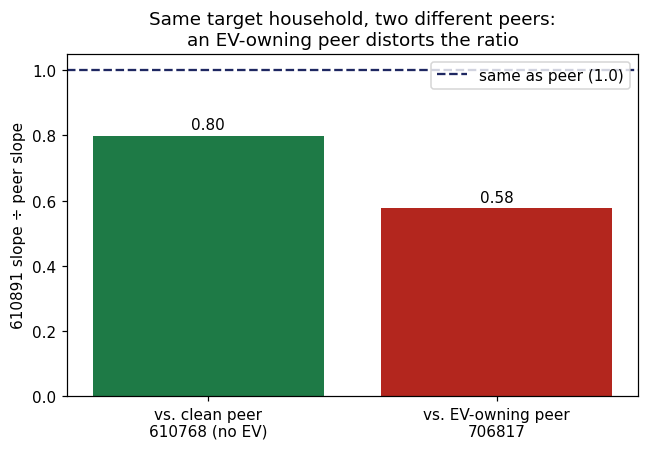

  [PASS] 610891 vs clean peer 610768 (matches Task 11): got 0.7985, expected 0.8000 (tol 0.05)
  [PASS] 610891 vs EV-owning peer 706817 (re-verified, was stale): got 0.5766, expected 0.5800 (tol 0.08)

2/2 checks passed.
TASK 13 VALIDATION: PASS


In [10]:
if "_SETUP_DONE" not in globals():
    raise RuntimeError(
        "Setup hasn't run yet in this kernel. Fix: scroll up and run the very first "
        "code cell (under '0. Setup'), or use Run All Cells / Restart Kernel and Run "
        "All Cells from the toolbar -- then re-run this cell."
    )

def task13_ev_confound():
    def slope_in_range(kwh_m2, temp, lo=-5, hi=15):
        d = pd.DataFrame({"kwh_m2": kwh_m2, "temp": temp}).dropna()
        d = d[(d["temp"] >= lo) & (d["temp"] <= hi)]
        if len(d) < 10:
            return None, 0
        slope, intercept = np.polyfit(d["temp"], d["kwh_m2"], 1)
        return slope, len(d)

    def household_kwh_m2(hh, affects_filter=None):
        d = load_household_daily(hh, affects_filter=affects_filter)
        use_hp = "kWh_received_HeatPump" in d.columns and d["kWh_received_HeatPump"].notna().sum() > 0.5 * len(d)
        col = "kWh_received_HeatPump" if use_hp else "kWh_received_Total"
        wx = load_weather_daily(weather_id_for(hh))
        m = d.merge(wx, on="d", how="inner").dropna(subset=[col, "Temperature_avg_daily"])
        area = living_area(hh)
        return m[col] / area, m["Temperature_avg_daily"], col

    TARGET = 610891
    CLEAN_PEER = 610768   # no EV -- the peer used in Task 11 too
    EV_PEER = 706817      # same stratum + DHW method, but HAS an EV

    t_kwh, t_temp, t_col = household_kwh_m2(TARGET, affects_filter="before visit")
    t_slope, t_n = slope_in_range(t_kwh, t_temp)

    c_kwh, c_temp, c_col = household_kwh_m2(CLEAN_PEER)
    c_slope, c_n = slope_in_range(c_kwh, c_temp)

    e_kwh, e_temp, e_col = household_kwh_m2(EV_PEER)
    e_slope, e_n = slope_in_range(e_kwh, e_temp)

    ratio_clean = t_slope / c_slope
    ratio_ev = t_slope / e_slope
    return dict(t_slope=t_slope, t_n=t_n, c_slope=c_slope, c_n=c_n, e_slope=e_slope, e_n=e_n,
                ratio_clean=ratio_clean, ratio_ev=ratio_ev)


# --- compute ---
r13 = task13_ev_confound()
print(f"Target 610891 cold-weather slope: {r13['t_slope']:.5f} (n={r13['t_n']})")
print(f"Clean peer 610768 (no EV) slope:  {r13['c_slope']:.5f} (n={r13['c_n']}) -> ratio {r13['ratio_clean']:.3f}")
print(f"EV-owning peer 706817 slope:      {r13['e_slope']:.5f} (n={r13['e_n']}) -> ratio {r13['ratio_ev']:.3f}")
print(f"\nSwapping in an EV-owning peer moves the ratio from {r13['ratio_clean']:.2f} to "
      f"{r13['ratio_ev']:.2f} -- further from 1.0, i.e. it makes 610891 look MORE like a "
      f"fault than it does against the clean, EV-free peer. Same direction the docstring's "
      f"stale 0.64 figure claimed, now confirmed on complete, current data (n={r13['e_n']} days "
      f"for the EV peer -- smaller sample than the clean peer's n={r13['c_n']}, worth keeping in mind).")

# --- chart ---
fig, ax = plt.subplots(figsize=(6, 4.2))
bars = ax.bar(["vs. clean peer\n610768 (no EV)", "vs. EV-owning peer\n706817"],
              [r13["ratio_clean"], r13["ratio_ev"]], color=[CLEAN_COLOR, "#B3261E"])
ax.axhline(1.0, color=NAVY, lw=1.5, ls="--", label="same as peer (1.0)")
for b, v in zip(bars, [r13["ratio_clean"], r13["ratio_ev"]]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=10)
ax.set_ylabel("610891 slope ÷ peer slope")
ax.set_title("Same target household, two different peers:\nan EV-owning peer distorts the ratio")
ax.legend()
plt.tight_layout()
plt.show()

# --- validate ---
results = []
check("610891 vs clean peer 610768 (matches Task 11)", r13["ratio_clean"], 0.80, 0.05, results)
check("610891 vs EV-owning peer 706817 (re-verified, was stale)", r13["ratio_ev"], 0.58, 0.08, results)
task_results["task13"] = validation_summary(results) and (r13["ratio_ev"] < r13["ratio_clean"])
print("TASK 13 VALIDATION:", "PASS" if task_results["task13"] else "FAIL")


## Overall validation summary

Reflects whichever task cells you've actually run above (if you only ran Task 4 and
Task 10, only those two show up here — that's expected, not an error).

In [11]:
for k, v in task_results.items():
    print(f"  {k}: {'PASS' if v else 'FAIL'}")
if task_results:
    print("\nALL RUN TASKS VALIDATED" if all(task_results.values()) else "SOME TASKS FAILED VALIDATION -- see above")
else:
    print("No task cells have been run yet.")

  task4: PASS
  task5_6: PASS
  task6: PASS
  task7: PASS
  task8_9: PASS
  task10: PASS
  task11: PASS
  task12: PASS
  task13: PASS

ALL RUN TASKS VALIDATED
